# Exercícios de Regressão Logística e Classificação Binária
Aluno: Kauã de Oliveira Ribeiro

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$

### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$

### c) Classificação final

- Se $\hat{y} > 0.5$ → Classe 1  
- Caso contrário → Classe 0  

## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$?  
2. Qual o papel do $b$?  
3. Por que usamos a função sigmoide?

Dica:

- $w$ → importância de cada variável  
- $b$ → ajuste da linha  
- Sigmoide → transforma em probabilidade  

Tarefa 1:

a)
$$
z = w_1 x_1 + w_2 x_2 + b
$$

$$
z = 2.0 * 1.2 + (-1.0) * (- 0.3) + 0.5
$$

$$
z = 2.4 + 0.3 + 0.5
$$

$$
z = 3.2
$$



b)
$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$

$$
\hat{y} = \frac{1}{1 + e^{-3.2}}
$$

$$
\hat{y} = \frac{1}{1 + 0.0476}
$$

$$
\hat{y} = \frac{1}{1.0476}
$$

$$
\hat{y} = 0.960834
$$



c) Como o valor encontrado para $\hat{y}$ foi de 0.960834, ou seja, maior do que 0.5, trata-se de um conjunto de classe 1.

Tarefa 2:

1. Os valores de $w_1$ e $w_2$ são os pesos das variáveis da função dada, com $w_1$ determinando a influência de $x_1$ no resultado de z e, respectivamente, $w_2$ o de $x_2$. Quanto maior forem esses valores, mais importante serão as variáveis as quais eles acompanham em relação aos outros parâmetros.

2. O bias faz o ajuste, horizontal ou vertical, da função encontrada ao problema, é o coeficiente linear da função dada. Ele não altera a curva prevista, mas desloca-a para adequar as predições realizadas pelo algoritmo ao problema dado.

3. A função sigmoide é utilizada para adequar a saída da regressão linear, cujos pesos são $w_1$ e $w_2$, entre 0 e 1, determinando a probabilidade desse valor fazer parte de uma classe ou de outra. (Classe 0 caso $\hat{y} <= 0.5$ ou Classe 1 caso $\hat{y} > 0.5$)

# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

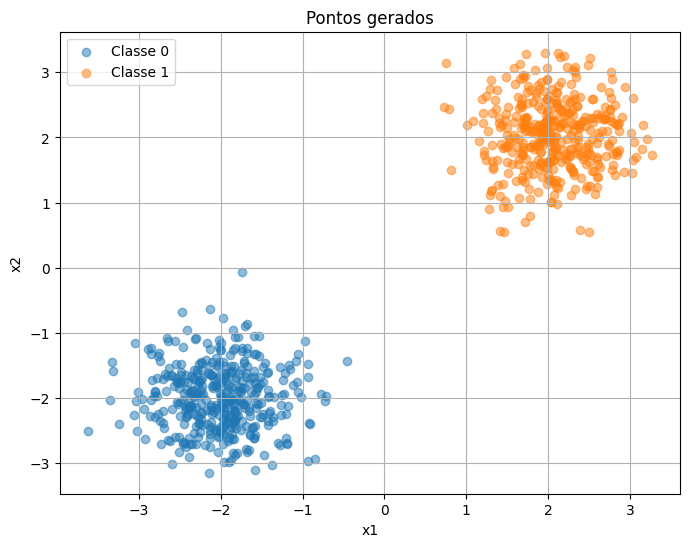

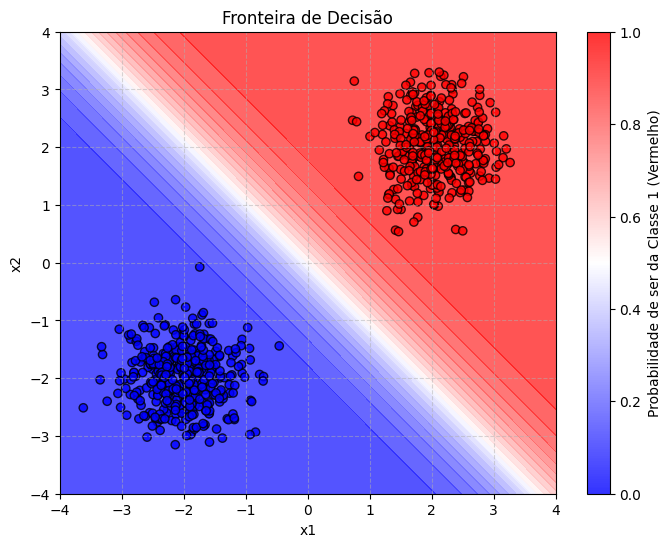

[1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1.
 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.
 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Seed escolhida (Importante para sempre manter os dados gerados iguais)
np.random.seed(42)

# Número de amostras geradas
N = 400

# Gera dados distribuidos ao redor de -2
# Classe 0
x0 = np.random.randn(N, 2) * 0.5 - 2
y0 = np.zeros(N)

# Gera dados distribuidos ao redor de 2
# Classe 1
x1 = np.random.randn(N, 2) * 0.5 + 2
y1 = np.ones(N)

# Juntar dados
X = np.vstack([x0, x1])
Y = np.hstack([y0, y1])

# Separar treino e teste
# Evita que o modelo se adeque unicamente aos dados utilizados ao longo do treinamento
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# Treinar modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Plot dos dados gerados
plt.figure(figsize=(8,6))

plt.scatter(x0[:,0], x0[:,1], alpha=0.5, label="Classe 0")
plt.scatter(x1[:,0], x1[:,1], alpha=0.5, label="Classe 1")

plt.title("Pontos gerados")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Criando uma malha de pontos bidimensional para visualizar a fronteira de decisão da regressão linear
xx, yy = np.meshgrid(np.linspace(-4, 4, 200),
                     np.linspace(-4, 4, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plotando a fronteira com o mapa de cores Blue-White-Red (0=Azul, 1=Vermelho)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")

# Plotando os pontos no gráfico
# C=Y faz com que 0 seja Azul e 1 seja Vermelho no cmap 'bwr'
plt.scatter(X[:,0], X[:,1], c=Y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Fronteira de Decisão")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Probabilidade de ser da Classe 1 (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(y_pred)

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

Acurácia do modelo treinado:  0.9619047619047619 



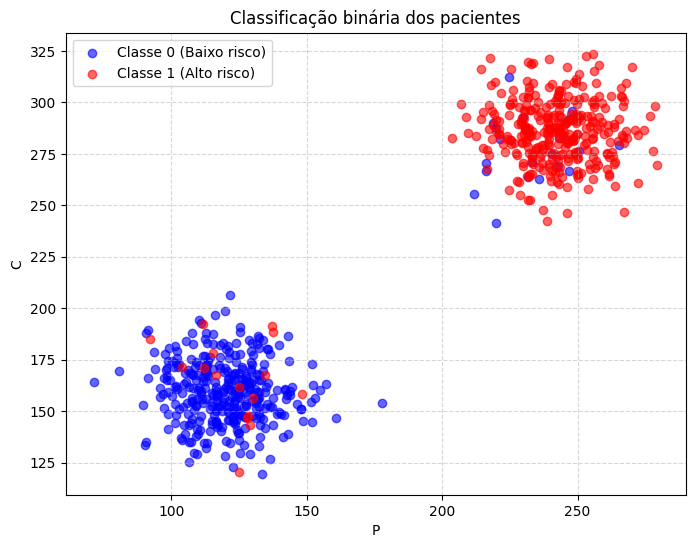

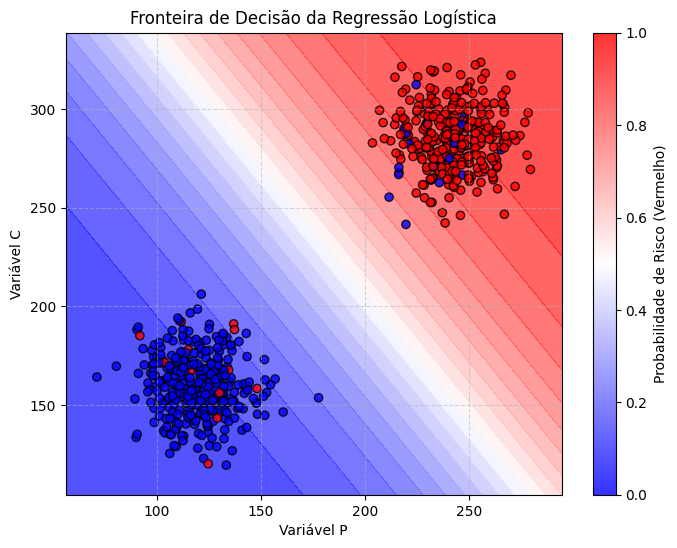

[0 1 1 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1
 1 1 0 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 1 0 0 0 1 0 0 0 0
 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0
 1 0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 1 0 0 1
 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 1]


In [10]:
# Importa as bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Seed escolhida (Importante para sempre manter os dados gerados iguais)
np.random.seed(42)

# 1. Simular 700 pacientes
n = 700
n_baixo_risco = int(n * 0.5)
n_alto_risco = n - n_baixo_risco

# Supondo P como Pressão e C como Colesterol

# Grupo de baixo risco
P1 = np.random.randn(n_baixo_risco) * 15 + 120
C1 = np.random.randn(n_baixo_risco) * 15 + 160

# Grupo de alto risco
P2 = np.random.randn(n_alto_risco) * 15 + 240
C2 = np.random.randn(n_alto_risco) * 15 + 285

# Juntando os dados de P1 e P2 em P e de C1 e C2 em C
P = np.concatenate([P1, P2])
C = np.concatenate([C1, C2])

# Criando a matriz X desejada a partir dos dados de P e C
X = np.column_stack((P, C))

# 2. Calcular a probabilidade p a partir da fórmula descrita no problema
z = (0.03 * P) + (0.02 * C) - 10
p = 1 / (1 + np.exp(-z))

# 3. Gerar a classe 'Y' baseada na probabilidade
Y = np.random.binomial(1, p)

# Separar os dados entre treino e teste
# Evita que o modelo se adeque unicamente aos dados utilizados ao longo do treinamento
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# 4. Treinar modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)
print("Acurácia do modelo treinado: ", model.score(X_test, y_test), "\n")

# 5. Plot dos dados gerados
plt.figure(figsize=(8,6))

plt.scatter(X[Y==0, 0], X[Y==0, 1], alpha=0.6, label="Classe 0 (Baixo risco)", c='blue')
plt.scatter(X[Y==1, 0], X[Y==1, 1], alpha=0.6, label="Classe 1 (Alto risco)", c='red')

plt.title("Classificação binária dos pacientes")
plt.xlabel("P")
plt.ylabel("C")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 6. Fronteira de Decisão
# Criando uma malha de pontos bidimensional para visualizar a fronteira de decisão da regressão linear com base nos limites de P e C gerados
x_min, x_max = P.min() - 15, P.max() + 15
y_min, y_max = C.min() - 15, C.max() + 15

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs_grid = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plotando a fronteira com o mapa de cores Blue-White-Red (0=Azul, 1=Vermelho)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs_grid, levels=20, alpha=0.7, cmap="bwr")

# Plotando os pontos no gráfico
# C=Y faz com que 0 seja Azul e 1 seja Vermelho no cmap 'bwr'
plt.scatter(X[:,0], X[:,1], c=Y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Fronteira de Decisão da Regressão Logística")
plt.xlabel("Variável P")
plt.ylabel("Variável C")
plt.colorbar(label="Probabilidade de Risco (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(y_pred)